##**PEMAHAMAN DATA**

Dataset Life Expectancy berisikan berbagai variabel yang memperlihatkan kondisi kesehatan dan sosial-ekonomi suatu negara.

Variabel utamanya adalah Life Expectancy, yaitu rata-rata usia harapan hidup sejak lahir, yang sangat dipengaruhi oleh faktor kesehatan dan kesejahteraan masyarakat.

Indikator kematian ditunjukkan oleh Adult Mortality (angka kematian orang dewasa usia 15-60 tahun), Infant Deaths (kematian bayi di bawah 1 tahun), serta Under-five Deaths (kematian anak di bawah 5 tahun) yang menggambarkan kualitas layanan kesehatan dasar.

Faktor gaya hidup dan status gizi terlihat dari variabel Alcohol yang mengukur konsumsi rata-rata alkohol per kapita, BMI sebagai indikator status gizi rata-rata, serta Thinness pada kelompok usia 1-19 tahun dan 5-9 tahun yang menggambarkan prevalensi kekurangan gizi.

Variabel cakupan imunisasi seperti Polio, Diphtheria, dan Measles memberikan gambaran mengenai tingkat perlindungan kesehatan anak, sementara HIV/AIDS menunjukkan angka kematian akibat penyakit menular tersebut.

Dari sisi sosial-ekonomi, terdapat Income Composition of Resources sebagai indeks distribusi pendapatan, GDP per kapita sebagai indikator kekuatan ekonomi, serta Total Expenditure yang menunjukkan porsi anggaran pemerintah untuk kesehatan.

Population mencatat jumlah penduduk tiap negara, sedangkan Schooling mengukur rata-rata lama sekolah yang menjadi indikator tingkat pendidikan.

In [ ]:
import pandas as pd
df = pd.read_csv('/content/Life Expectancy Data.csv')

In [ ]:
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [ ]:
df.shape

(2938, 22)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [ ]:
df.isnull().sum()

,0
Country,0
Year,0
Status,0
Life expectancy,10
Adult Mortality,10
infant deaths,0
Alcohol,194
percentage expenditure,0
Hepatitis B,553
Measles,0


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
df.columns = df.columns.str.strip()

#Imputasi dengan median per negara (kolom dengan missing kecil)
median_cols = [
    "Life expectancy", "Adult Mortality", "BMI",
    "Polio", "Diphtheria", "thinness  1-19 years", "thinness 5-9 years"
]

for col in median_cols:
    df[col] = df.groupby("Country")[col].transform(lambda x: x.fillna(x.median()))

#Imputasi dengan media global (kolom missing sedang)
median_global_cols = [
    "Alcohol", "Total expenditure", "Income composition of resources", "Schooling"
]

for col in median_global_cols:
    df[col] = df[col].fillna(df[col].median())

#Interpolasi per negara untuk data time-series (GDP dan Populasi)
for col in ["GDP", "Population"]:
    df[col] = df.groupby("Country")[col].transform(lambda x: x.interpolate(method="linear"))

#Kolom dengan banyak missing dan tidak relevan
df = df.drop(columns=["Hepatitis B"])

print(df.isnull().sum())

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                              0
percentage expenditure               0
Measles                              0
BMI                                 34
under-five deaths                    0
Polio                                0
Total expenditure                    0
Diphtheria                           0
HIV/AIDS                             0
GDP                                422
Population                         652
thinness  1-19 years                34
thinness 5-9 years                  34
Income composition of resources      0
Schooling                            0
dtype: int64


In [ ]:
#Imputasi dengan median per negara (kolom dengan missing kecil)
median_cols = [
    "Life expectancy", "Adult Mortality", "BMI",
    "thinness  1-19 years", "thinness 5-9 years"
]

for col in median_cols:
    df[col] = df.groupby("Country")[col].transform(lambda x: x.fillna(x.median()))
    df[col] = df[col].fillna(df[col].median())  # fallback kalau masih ada NaN

#Imputasi median global (kolom missing sedang)
median_global_cols = [
    "Alcohol", "Total expenditure", "Income composition of resources", "Schooling"
]

for col in median_global_cols:
    df[col] = df[col].fillna(df[col].median())

#Interpolasi per negara untuk time-series (GDP & Population)
for col in ["GDP", "Population"]:
    if col in df.columns:
        df[col] = df.groupby("Country")[col].transform(lambda x: x.interpolate(method="linear"))
        df[col] = df[col].fillna(df[col].median())  # fallback isi median global

print(df.isnull().sum())

Country                            0
Year                               0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Measles                            0
BMI                                0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
HIV/AIDS                           0
GDP                                0
Population                         0
thinness  1-19 years               0
thinness 5-9 years                 0
Income composition of resources    0
Schooling                          0
dtype: int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2938 non-null   float64
 4   Adult Mortality                  2938 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2938 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Measles                          2938 non-null   int64  
 9   BMI                              2938 non-null   float64
 10  under-five deaths                2938 non-null   int64  
 11  Polio                            2938 non-null   float64
 12  Total expenditure   

In [ ]:
df["Country"] = df["Country"].astype("category")
df["Status"] = df["Status"].astype("category")


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   Country                          2938 non-null   category
 1   Year                             2938 non-null   int64   
 2   Status                           2938 non-null   category
 3   Life expectancy                  2938 non-null   float64 
 4   Adult Mortality                  2938 non-null   float64 
 5   infant deaths                    2938 non-null   int64   
 6   Alcohol                          2938 non-null   float64 
 7   percentage expenditure           2938 non-null   float64 
 8   Measles                          2938 non-null   int64   
 9   BMI                              2938 non-null   float64 
 10  under-five deaths                2938 non-null   int64   
 11  Polio                            2938 non-null   float64 
 12  Total 

Untuk variabel dengan missing kecil seperti Life Expectancy, Adult Mortality, BMI, Polio, dan Thinness, imputasi dilakukan menggunakan median per negara agar nilai yang hilang tetap konsisten dengan karakteristik masing-masing negara.

Pada variabel dengan missing sedang seperti Alcohol, Total Expenditure, Income Composition of Resources, dan Schooling, digunakan median global karena lebih stabil dan tidak terpengaruh oleh outlier.

Sementara itu, variabel deret waktu seperti GDP dan Population diimputasi dengan interpolasi linear per negara agar mengikuti pola pertumbuhan dari waktu ke waktu, dengan median global sebagai fallback jika interpolasi tidak memungkinkan.

Variabel dengan missing terlalu besar dan kurang relevan, seperti Hepatitis B, dihapus untuk menghindari bias. Pendekatan ini dipilih agar imputasi tetap realistis, tidak bias, serta mempertahankan pola data yang sebenarnya.


variabel kategorikal seperti Country dan Status diubah tipenya menjadi category untuk menghemat memori serta menegaskan bahwa variabel tersebut bersifat kategorikal, bukan numerik.

##**STATISTIK DESKRIPTIF**

In [ ]:
categorical_vars = ["Country", "Status"]

health_vars = ["Life expectancy", "Adult Mortality", "infant deaths",
               "under-five deaths", "HIV/AIDS", "Measles"]

lifestyle_vars = ["Alcohol", "BMI", "Polio", "Diphtheria",
                  "Total expenditure", "thinness  1-19 years", "thinness 5-9 years"]

economic_vars = ["GDP", "Population", "Income composition of resources",
                 "Schooling", "percentage expenditure"]


def summary_stats(df, cols):
    desc = df[cols].describe().T
    desc["median"] = df[cols].median()
    desc["mode"] = df[cols].mode().iloc[0]
    desc["range"] = desc["max"] - desc["min"]
    return desc[["mean", "median", "mode", "std", "min", "max", "range"]]

#Statistik numerik per kelompok
print("Statistik Deskriptif - Kesehatan")
print(summary_stats(df, health_vars), "\n")

print("Statistik Deskriptif - Gaya Hidup")
print(summary_stats(df, lifestyle_vars), "\n")

print("Statistik Deskriptif - Ekonomi & Pendidikan")
print(summary_stats(df, economic_vars), "\n")

#Statistik kategorikal
print("Frekuensi Kategori")

# Country -> menampilkan jumlah tahun observasi top 10 negara
print("\nJumlah tahun observasi, top 10 Country:")
print(df["Country"].value_counts().head(10))

# Status -> Developed vs Developing
print("\nStatus:")
print(df["Status"].value_counts())


Statistik Deskriptif - Kesehatan
                          mean  median  mode           std   min       max  \
Life expectancy      69.234717    72.1  73.0      9.509115  36.3      89.0   
Adult Mortality     164.725664   144.0  12.0    124.086215   1.0     723.0   
infant deaths        30.303948     3.0   0.0    117.926501   0.0    1800.0   
under-five deaths    42.035739     4.0   0.0    160.445548   0.0    2500.0   
HIV/AIDS              1.742103     0.1   0.1      5.077785   0.1      50.6   
Measles            2419.592240    17.0   0.0  11467.272489   0.0  212183.0   

                      range  
Life expectancy        52.7  
Adult Mortality       722.0  
infant deaths        1800.0  
under-five deaths    2500.0  
HIV/AIDS               50.5  
Measles            212183.0   

Statistik Deskriptif - Gaya Hidup
                           mean  median    mode        std   min    max  range
Alcohol                4.546875   3.755   0.010   3.921946  0.01  17.87  17.86
BMI             

Hasil statistik deskriptif menunjukkan bahwa variabel kesehatan memiliki pola yang cukup beragam. Rata-rata Life Expectancy mencapai sekitar 69 tahun, dengan sebaran dari 36 hingga 89 tahun, menandakan adanya perbedaan signifikan antarnegara. Angka kematian dewasa (Adult Mortality) masih relatif tinggi dengan rata-rata 165 per 1.000 orang, sementara angka kematian bayi dan balita memiliki distribusi yang sangat lebar, dari nol hingga ribuan kasus, menunjukkan adanya ketimpangan layanan kesehatan dasar.


Penyakit menular seperti HIV/AIDS memiliki rata-rata rendah (1,7) namun dengan outlier sangat tinggi di beberapa negara, sedangkan kasus campak (Measles) menunjukkan variasi ekstrem dengan deviasi standar besar. Dari sisi gaya hidup, konsumsi alkohol rata-rata 4,5 liter per kapita, BMI rata-rata 38, dan prevalensi thinness relatif rendah. Cakupan imunisasi seperti Polio dan Diphtheria cukup tinggi, tetapi tetap ada negara dengan cakupan sangat rendah.


Dari perspektif ekonomi dan pendidikan, rata-rata GDP per kapita sekitar 6.600 namun dengan rentang sangat lebar, dari ribuan hingga lebih dari 100 ribu, serta populasi yang sangat bervariasi dari puluhan hingga miliaran. Indeks Income Composition of Resources cukup baik dengan rata-rata 0,63, sedangkan rata-rata lama sekolah (Schooling) mencapai 12 tahun. Distribusi kategori menunjukkan bahwa mayoritas data berasal dari negara Developing dibandingkan negara Developed, dan hampir semua negara memiliki data lengkap untuk 16 tahun observasi.

##**VISUALISASI DATA**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df.columns = df.columns.str.strip()

num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'Year' in num_cols:
    num_cols.remove('Year')


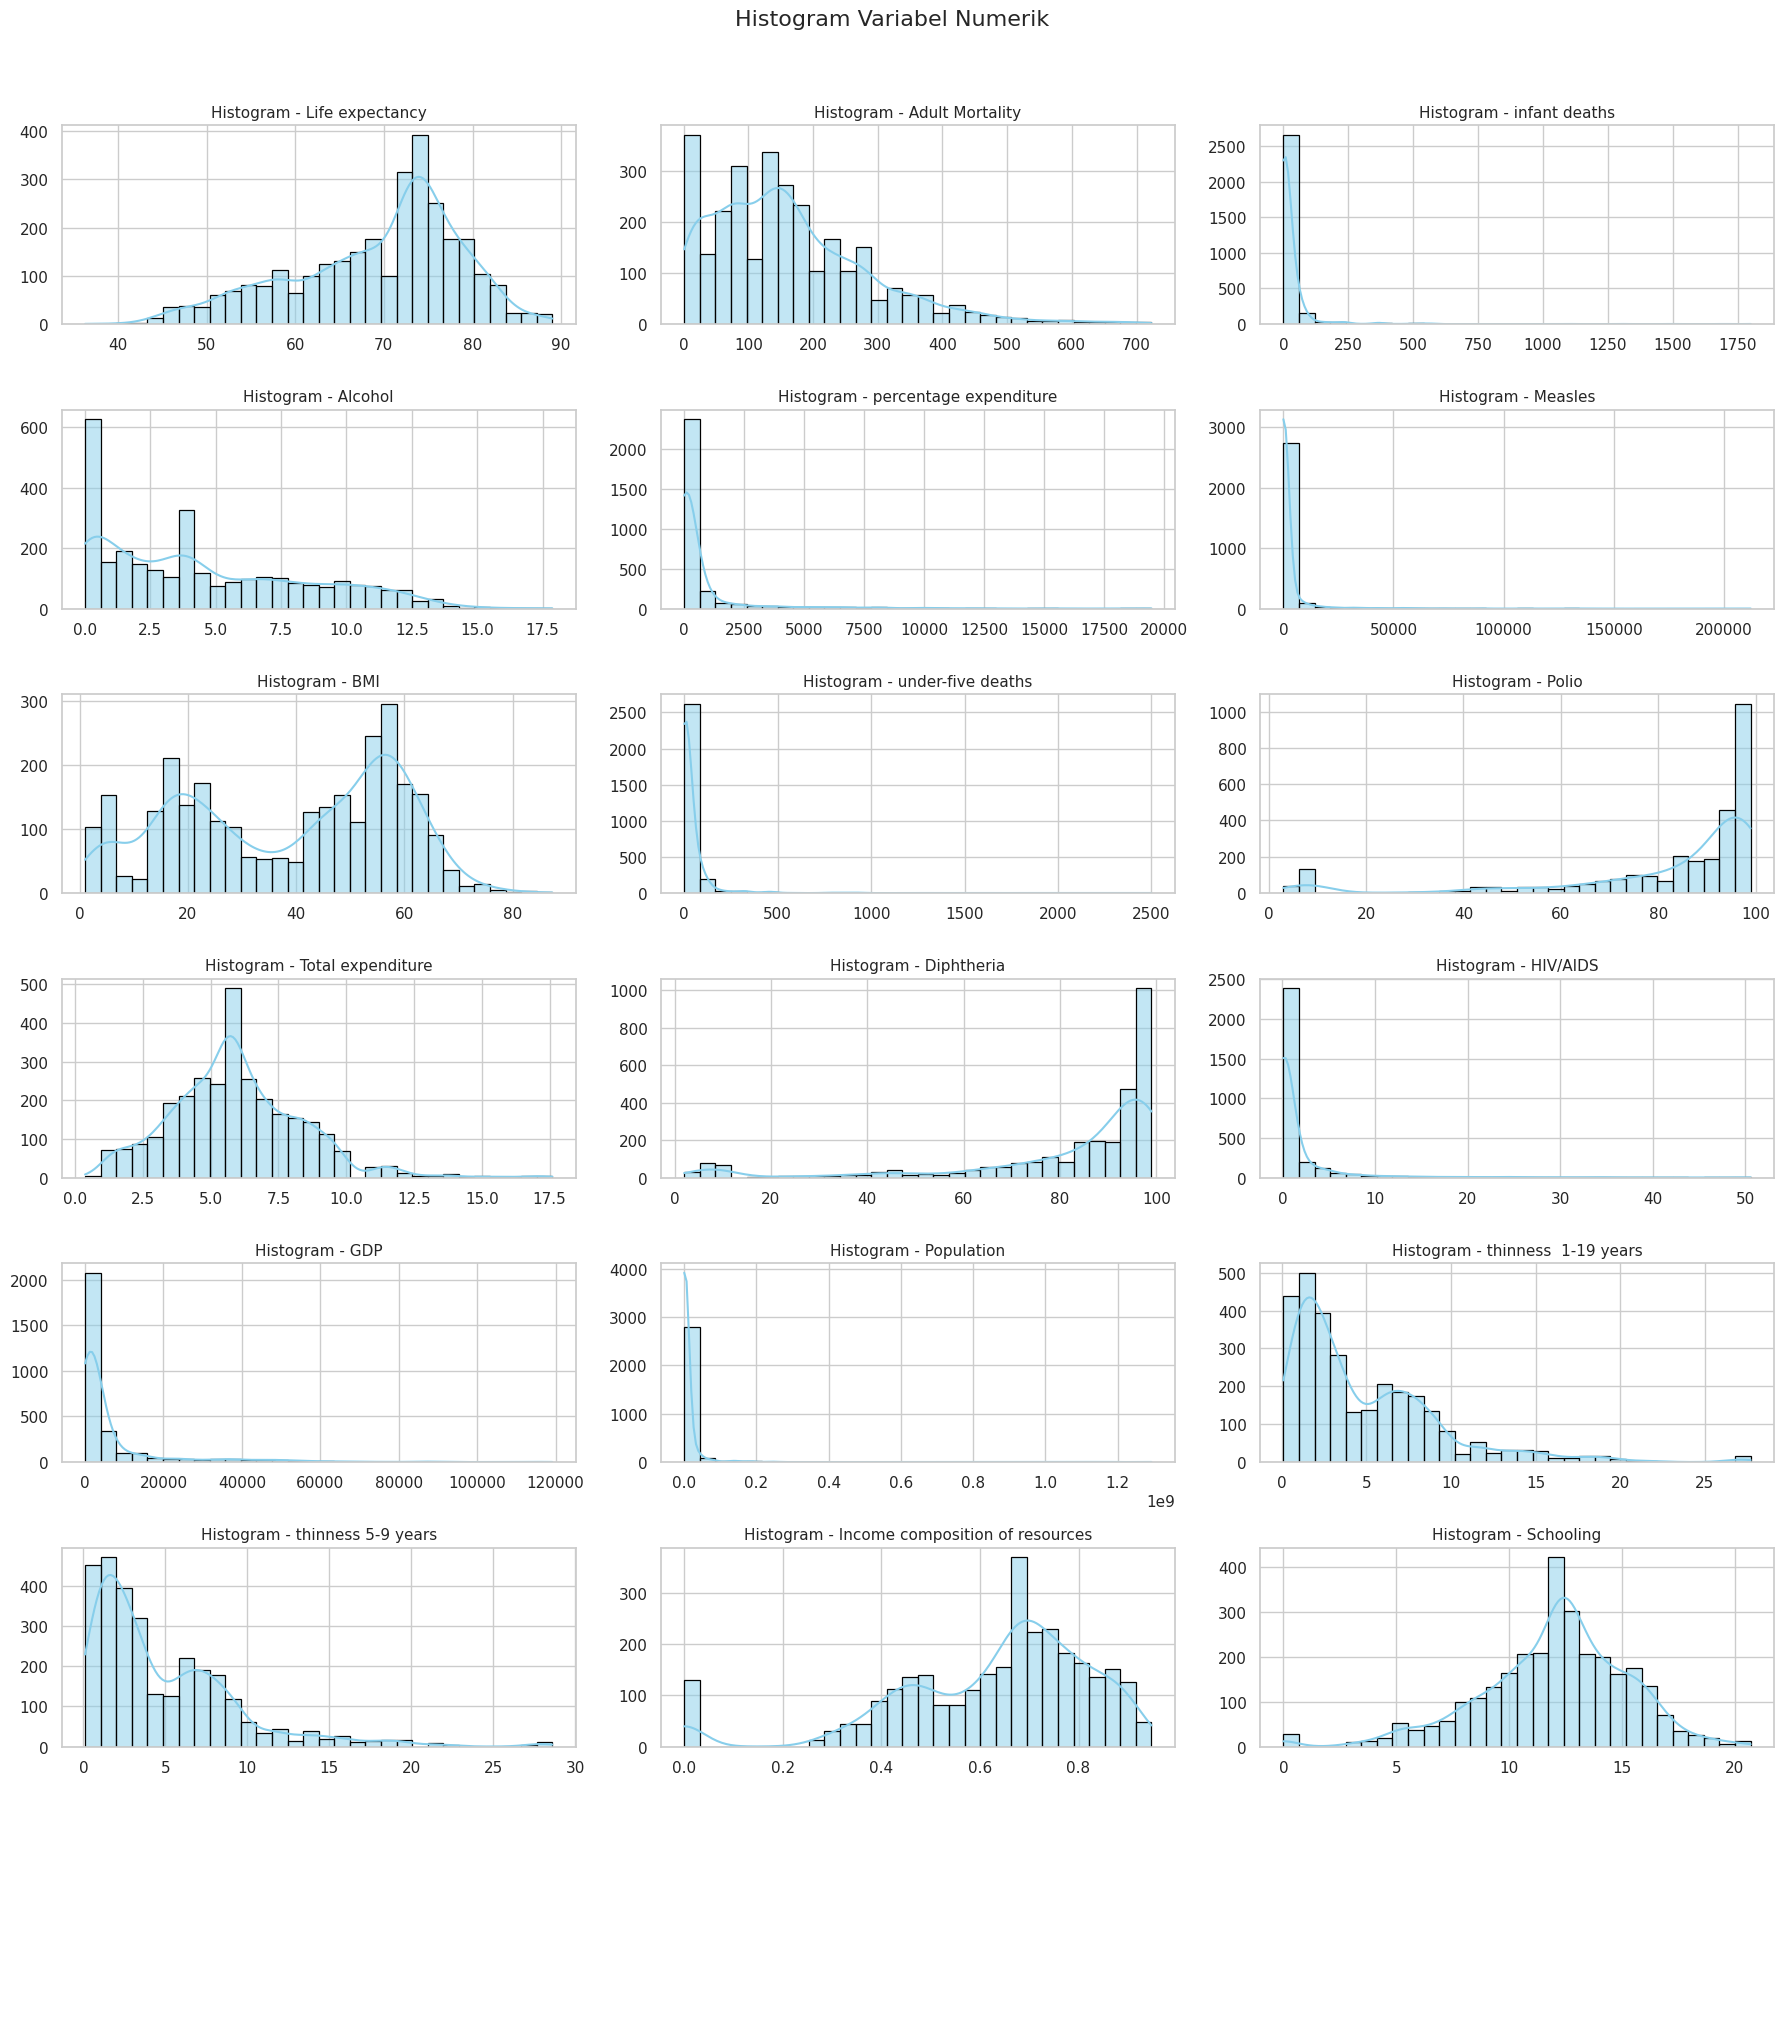

In [ ]:
#NUMERIK

# Histogram
fig, axes = plt.subplots(nrows=len(num_cols)//3 + 1, ncols=3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color="skyblue", edgecolor="black")
    axes[i].set_title(f"Histogram - {col}", fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Histogram Variabel Numerik", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()



Hasil histogram variabel numerik menunjukkan bahwa sebagian besar variabel seperti Adult Mortality, Infant Deaths, Under-five Deaths, Alcohol, Total Expenditure, GDP, dan Population memiliki distribusi yang miring ke kanan (right-skewed), artinya mayoritas negara berada pada nilai rendah dengan sedikit negara yang memiliki nilai ekstrem tinggi sebagai outlier.


Variabel kesehatan seperti Measles, Diphtheria, Polio, dan HIV/AIDS juga menunjukkan pola serupa, di mana sebagian besar negara melaporkan kasus yang rendah namun terdapat beberapa negara dengan angka yang sangat tinggi.

Sebaliknya, variabel seperti Life Expectancy, Schooling, dan Income Composition of Resources cenderung mendekati distribusi normal, yang menunjukkan pola sebaran lebih merata antarnegara.

variabel BMI memperlihatkan distribusi multimodal, sementara indikator Thinness (usia 1-19 dan 5-9 tahun) memiliki pola distribusi yang hampir sama dengan mayoritas nilai berada pada kategori rendah. Hasil ini mengindikasikan adanya ketimpangan antarnegara, khususnya pada aspek kesehatan dan ekonomi, dengan beberapa negara ekstrem yang jauh berbeda dari mayoritas.

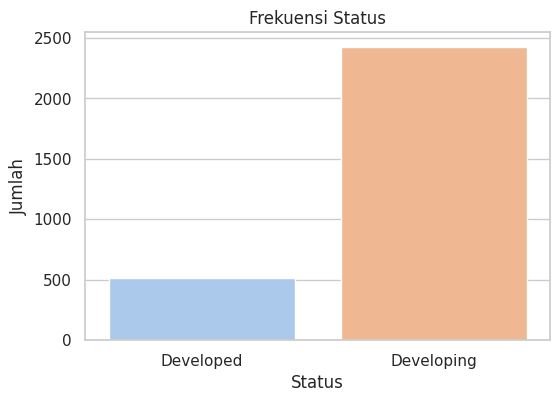

In [ ]:
#KATEGORIKAL

# Status
plt.figure(figsize=(6, 4))
sns.countplot(x="Status", data=df, hue="Status", palette="pastel", legend=False)
plt.title("Frekuensi Status")
plt.xlabel("Status")
plt.ylabel("Jumlah")
plt.show()



Bar chart di atas menunjukkan distribusi jumlah data berdasarkan status negara, yaitu Developed dan Developing. Terlihat bahwa jumlah data untuk negara Developing jauh lebih besar dibandingkan dengan Developed, dengan selisih yang signifikan. Hal ini menggambarkan bahwa mayoritas data dalam dataset berasal dari negara berkembang, sehingga analisis selanjutnya kemungkinan besar akan lebih mencerminkan kondisi negara berkembang dibandingkan negara maju.

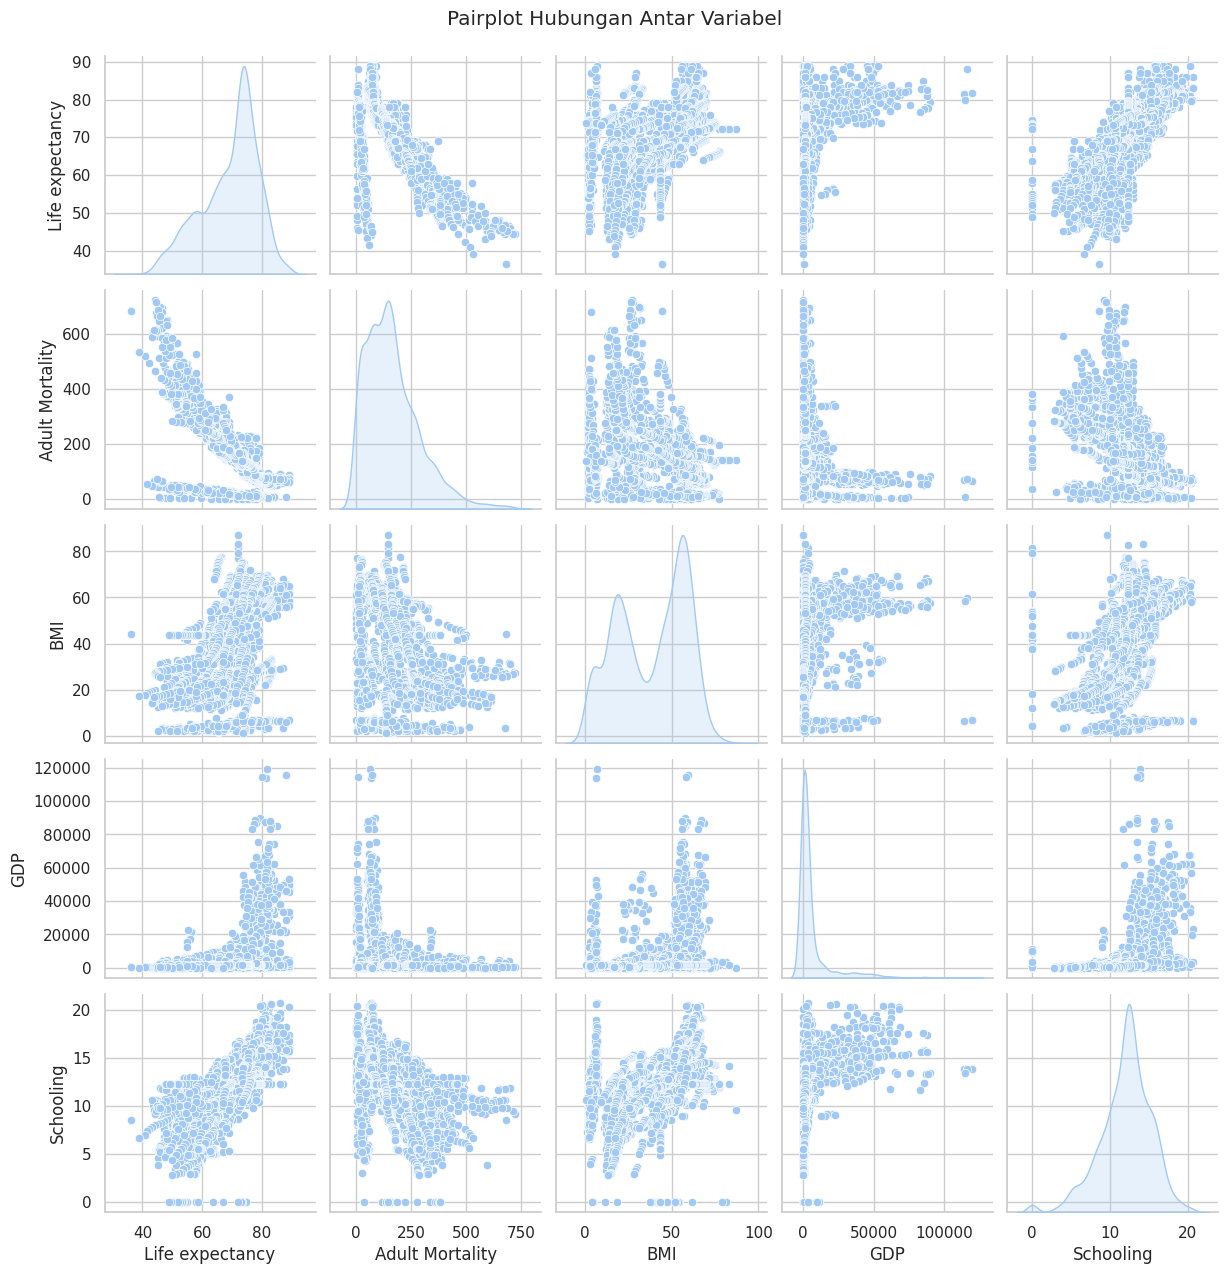

In [ ]:
#HUBUNGAN ANTAR VARIABEL

# Pairplot subset variabel penting
subset = ["Life expectancy", "Adult Mortality", "BMI", "GDP", "Schooling"]
sns.pairplot(df[subset], diag_kind="kde")
plt.suptitle("Pairplot Hubungan Antar Variabel", y=1.02)
plt.show()


Pairplot di atas memperlihatkan hubungan antarvariabel penting, yaitu Life Expectancy, Adult Mortality, BMI, dan GDP. Terlihat bahwa Life Expectancy memiliki hubungan negatif yang kuat dengan Adult Mortality, artinya semakin tinggi angka kematian orang dewasa maka semakin rendah harapan hidup. Sebaliknya, Life Expectancy cenderung meningkat seiring kenaikan BMI dan GDP, yang menunjukkan bahwa status gizi dan kondisi ekonomi berperan positif dalam memperpanjang usia harapan hidup

##**PENANGANAN OUTLIER**

In [ ]:
import numpy as np

outliers_iqr = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outliers_iqr[col] = outliers

for col, out in outliers_iqr.items():
    print(f"{col}: {len(out)} outlier")


Life expectancy: 17 outlier
Adult Mortality: 86 outlier
infant deaths: 315 outlier
Alcohol: 3 outlier
percentage expenditure: 389 outlier
Measles: 542 outlier
BMI: 0 outlier
under-five deaths: 394 outlier
Polio: 290 outlier
Total expenditure: 51 outlier
Diphtheria: 309 outlier
HIV/AIDS: 542 outlier
GDP: 445 outlier
Population: 452 outlier
thinness  1-19 years: 100 outlier
thinness 5-9 years: 99 outlier
Income composition of resources: 130 outlier
Schooling: 77 outlier


Saya memilih menggunakan metode box pot karena dataset ini memiliki banyak variabel dengan distribusi miring (skewed). Metode Z-score lebih sesuai untuk data distribusi normal, sementara box plot lebih fleksibel untuk data yang tidak normal dan mampu mendeteksi outlier ekstrem dengan lebih baik.

Saya memilih untuk mempertahankannya. Karena outlier ini bukan kesalahan pencatatan, tetapi merupakan variasi nyata antar negara, sehingga dapat diambil insightnya.
Dapat dilihat adanya perbedaan tajam antara negara maju dan berkembang dalam aspek ekonomi, kesehatan, maupun populasi.

Maka dari itu, daya outlier sangat penting untk dipertahankan agar analiss tetap menggambarkan kondisi sesungguhnya secara menyeluruh. Penghapusan outlier ini dapat menyebabkan informasi kritis hilang serta membuat hasila nalisis menjadi bias atau tidak representatif

##**KORELASI ANTAR VARIABEL**

In [ ]:
#Matriks korelasi
corr_matrix = df[num_cols].corr()
print("Matriks Korelasi Variabel Numerik:")
print(corr_matrix)


Matriks Korelasi Variabel Numerik:
                                 Life expectancy  Adult Mortality  \
Life expectancy                         1.000000        -0.696390   
Adult Mortality                        -0.696390         1.000000   
infant deaths                          -0.196769         0.078890   
Alcohol                                 0.388918        -0.190191   
percentage expenditure                  0.381418        -0.242628   
Measles                                -0.157767         0.031293   
BMI                                     0.556901        -0.379092   
under-five deaths                      -0.222738         0.094280   
Polio                                   0.470517        -0.280820   
Total expenditure                       0.208844        -0.111796   
Diphtheria                              0.484029        -0.280857   
HIV/AIDS                               -0.556703         0.523886   
GDP                                     0.431304        -0.282073   

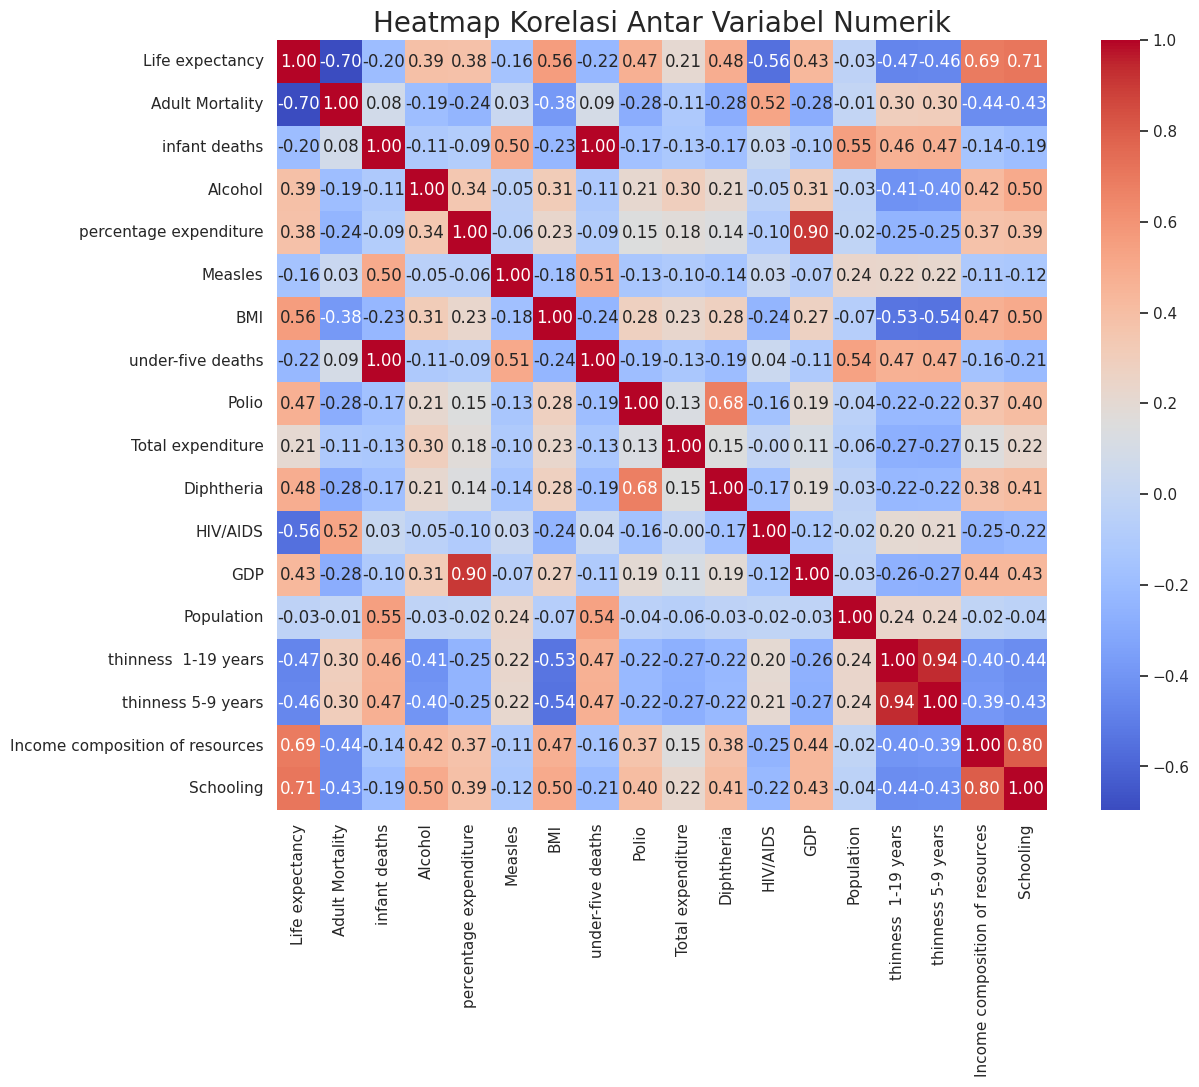

In [ ]:
#Visualisasi heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            cbar=True,
            square=True)

plt.title("Heatmap Korelasi Antar Variabel Numerik", fontsize=20)
plt.show()


Hasil analisis korelasi menunjukkan bahwa umur harapan hidup (life expectancy) memiliki hubungan positif yang cukup kuat dengan faktor pendidikan (schooling), kualitas sumber daya (income composition of resources), kondisi gizi (BMI), serta indikator ekonomi seperti PDB (GDP), yang berarti semakin tinggi pendidikan, kondisi gizi, dan kesejahteraan ekonomi suatu negara maka semakin tinggi pula umur harapan hidup penduduknya.

Sebaliknya, umur harapan hidup berkorelasi negatif dengan angka kematian dewasa (adult mortality), prevalensi HIV/AIDS, serta angka kematian anak, sehingga tingginya beban penyakit dan angka kematian berkontribusi menurunkan umur harapan hidup.

Selain itu, ditemukan  beberapa variabel yang memiliki korelasi sangat tinggi satu sama lain, seperti kematian bayi dan kematian balita, maupun indikator thinness usia 1-19 tahun dan 5-9 tahun, sehingga variabel-variabel ini berpotensi redundant dan dapat dipertimbangkan untuk direduksi dalam analisis lanjutan.

##**INSIGHT DATA**

**KESIMPULAN**

Dataset Life Expectancy menggambarkan keterkaitan erat antara faktor kesehatan, sosial, dan ekonomi terhadap umur harapan hidup suatu negara. Proses  yang dilakukan meliputi imputasi median per negara, median global, interpolasi deret waktu, penghapusan variabel dengan missing besar, serta konversi variabel kategorikal membantu menjaga kualitas data sehingga lebih siap dianalisis.


Hasil eksplorasi menunjukkan distribusi banyak variabel cenderung miring ke kanan dengan adanya outlier, yang menegaskan adanya ketimpangan antarnegara, sementara beberapa variabel seperti Life Expectancy, Schooling, dan Income Composition of Resources menunjukkan sebaran lebih merata. Analisis korelasi memperkuat temuan bahwa pendidikan, status gizi, dan kondisi ekonomi berkontribusi positif terhadap peningkatan harapan hidup, sedangkan tingginya angka kematian dewasa, kematian anak, dan prevalensi HIV/AIDS justru menurunkannya.

Dengan demikian, dapat disimpulkan bahwa peningkatan kualitas pendidikan, perbaikan gizi, dan penguatan aspek ekonomi merupakan faktor kunci untuk mendorong perbaikan umur harapan hidup suatu negara.

**REKOMENDASI LANGKAH ANALISIS BERIKUTNYA**

Sebagai langkah lanjutan, analisis dapat difokuskan pada pemodelan prediktif untuk mengidentifikasi faktor paling berpengaruh terhadap Life Expectancy, perbandingan antara negara Developed dan Developing, serta pengelompokan negara dengan karakteristik kesehatan dan ekonomi yang mirip melalui metode clustering. Selain itu, analisis tren waktu juga dapat dilakukan untuk melihat perkembangan kesehatan dan sosial-ekonomi dari tahun ke tahun.